### Importación de datos



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [2]:
IngresoTienda=tienda["Precio"].sum()
IngresoTienda2=tienda2["Precio"].sum()
IngresoTienda3=tienda3["Precio"].sum()
IngresoTienda4=tienda4["Precio"].sum()


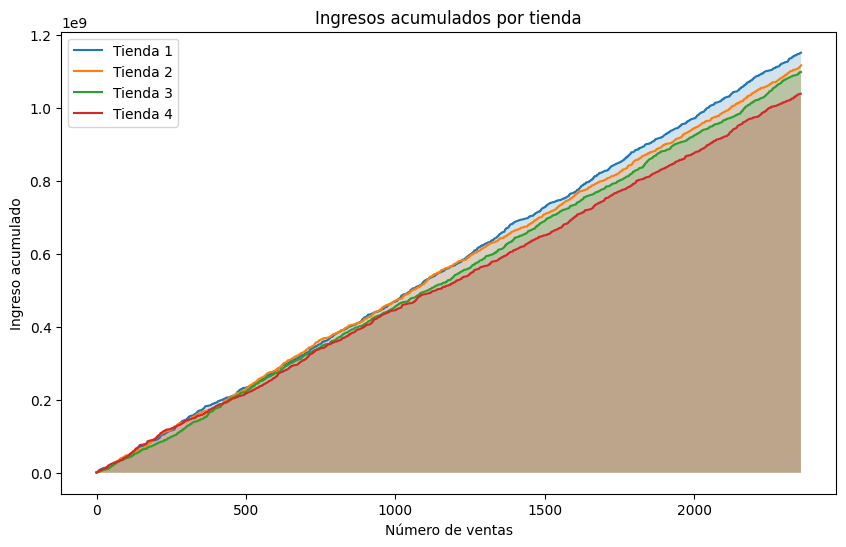

Ingresos totales por tienda:
Tienda 1: 1150880400.0
Tienda 2: 1116343500.0
Tienda 3: 1098019600.0
Tienda 4: 1038375700.0


In [3]:
import matplotlib.pyplot as plt

# suma acumulada
tienda["Ingreso_acum"] = tienda["Precio"].cumsum()
tienda2["Ingreso_acum"] = tienda2["Precio"].cumsum()
tienda3["Ingreso_acum"] = tienda3["Precio"].cumsum()
tienda4["Ingreso_acum"] = tienda4["Precio"].cumsum()

plt.figure(figsize=(10,6))

# plot
plt.plot(tienda.index, tienda["Ingreso_acum"], label="Tienda 1")
plt.plot(tienda2.index, tienda2["Ingreso_acum"], label="Tienda 2")
plt.plot(tienda3.index, tienda3["Ingreso_acum"], label="Tienda 3")
plt.plot(tienda4.index, tienda4["Ingreso_acum"], label="Tienda 4")

# Área bajo la curva
plt.fill_between(tienda.index, tienda["Ingreso_acum"], alpha=0.2)
plt.fill_between(tienda2.index, tienda2["Ingreso_acum"], alpha=0.2)
plt.fill_between(tienda3.index, tienda3["Ingreso_acum"], alpha=0.2)
plt.fill_between(tienda4.index, tienda4["Ingreso_acum"], alpha=0.2)

plt.title("Ingresos acumulados por tienda")
plt.xlabel("Número de ventas")
plt.ylabel("Ingreso acumulado")

plt.legend()
plt.show()

# Ingresos
print("Ingresos totales por tienda:")
print(f"Tienda 1: {IngresoTienda}")
print(f"Tienda 2: {IngresoTienda2}")
print(f"Tienda 3: {IngresoTienda3}")
print(f"Tienda 4: {IngresoTienda4}")

# 2. Ventas por categoría

In [4]:
VentasCategoriaTienda=tienda["Categoría del Producto"].value_counts()
VentasCategoriaTienda2=tienda2["Categoría del Producto"].value_counts()
VentasCategoriaTienda3=tienda3["Categoría del Producto"].value_counts()
VentasCategoriaTienda4=tienda4["Categoría del Producto"].value_counts()

In [5]:
def ventas_por_categoria(VentCatTienda):
  categorias = []
  ventas = []

  for categoria, venta in VentCatTienda.items():
      categorias.append(categoria)
      ventas.append(venta)

  return categorias, ventas

In [6]:
categorias, ventas = ventas_por_categoria(VentasCategoriaTienda)
categorias2, ventas2 = ventas_por_categoria(VentasCategoriaTienda2)
categorias3, ventas3 = ventas_por_categoria(VentasCategoriaTienda3)
categorias4, ventas4 = ventas_por_categoria(VentasCategoriaTienda4)

In [7]:
def graficas(x, y):
    plt.figure(figsize=(8,8))

    # Gráfico de Pastel
    plt.pie(y, labels=x, autopct='%1.1f%%', startangle=90, colors=plt.cm.tab20.colors)
    plt.title("Ventas por Categoría")
    plt.show()

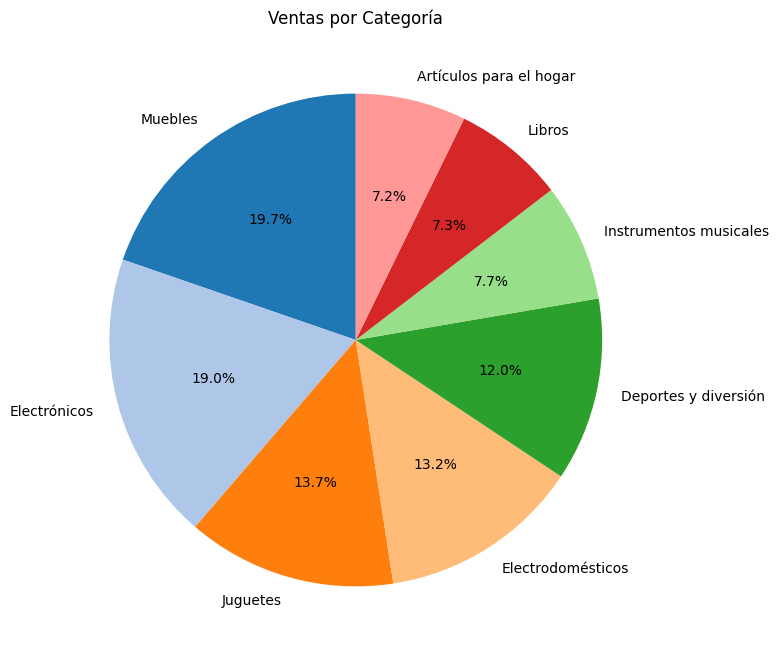

In [8]:
graficas(categorias, ventas )

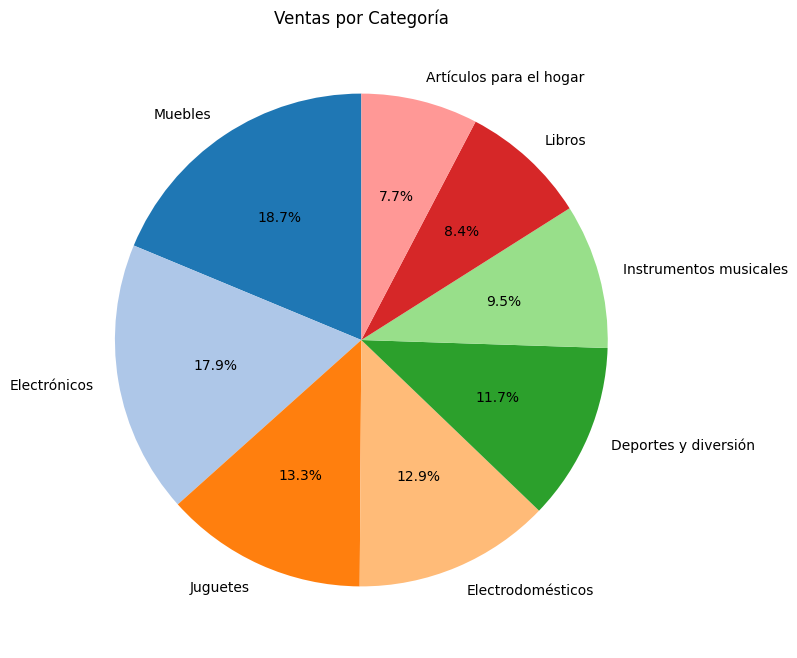

In [9]:
graficas(categorias2, ventas2 )

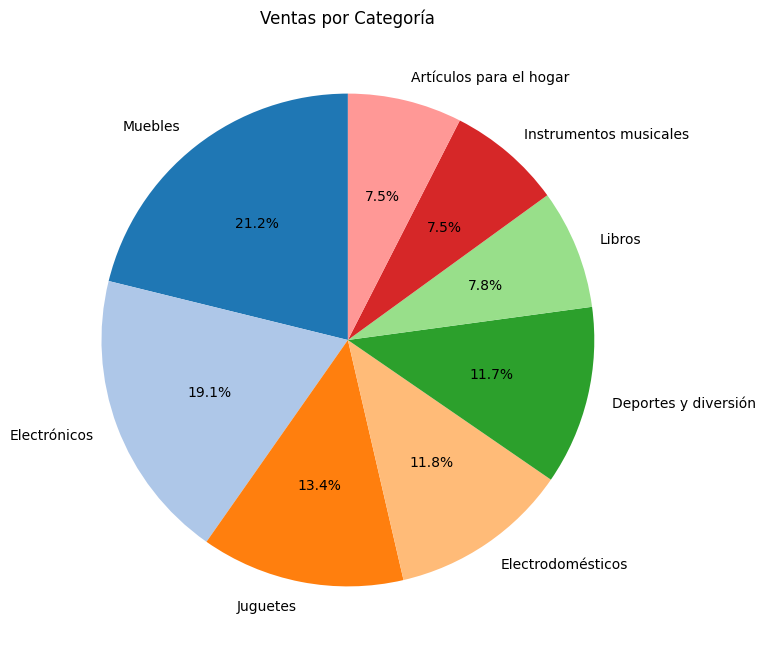

In [10]:
graficas(categorias3, ventas3 )

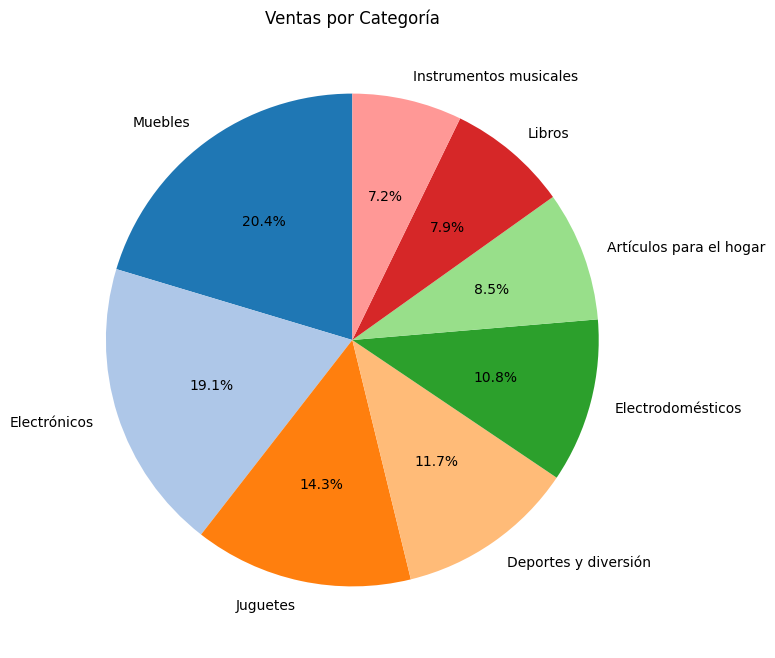

In [11]:
graficas(categorias4, ventas4 )

# 3. Calificación promedio de la tienda


In [12]:
CaliPromedioTienda=tienda["Calificación"].mean()
CaliPromedioTienda2=tienda2["Calificación"].mean()
CaliPromedioTienda3=tienda3["Calificación"].mean()
CaliPromedioTienda4=tienda4["Calificación"].mean()

In [13]:
CaliPromedioTienda4

np.float64(3.9957591178965224)

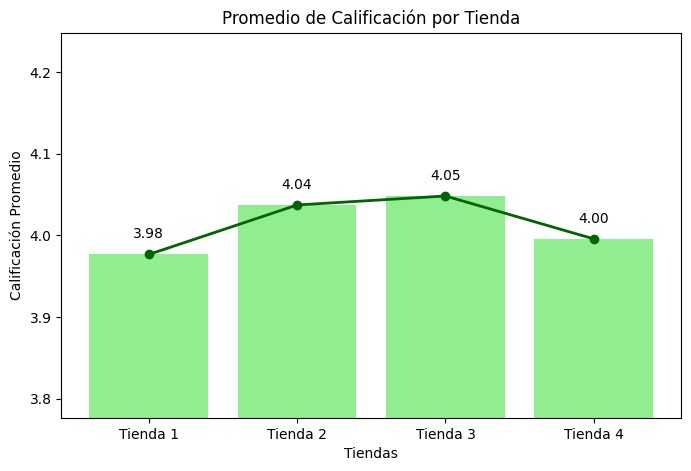

In [26]:
tiendas = ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"]
promedios = [CaliPromedioTienda, CaliPromedioTienda2, CaliPromedioTienda3, CaliPromedioTienda4]

plt.figure(figsize=(8,5))

# Barras
plt.bar(tiendas, promedios, color="lightgreen")

# plot
plt.plot(tiendas, promedios, color="darkgreen", marker="o", linewidth=2)

# Etiquetas
for i, valor in enumerate(promedios):
    plt.text(i, valor + 0.02, f"{valor:.2f}", ha='center')

plt.title("Promedio de Calificación por Tienda")
plt.xlabel("Tiendas")
plt.ylabel("Calificación Promedio")

plt.ylim(min(promedios)-0.2, max(promedios)+0.2)

plt.show()

# 4. Productos más y menos vendidos

In [15]:
VentasProductosTienda=tienda["Producto"].value_counts()
VentasProductosTienda2=tienda2["Producto"].value_counts()
VentasProductosTienda3=tienda3["Producto"].value_counts()
VentasProductosTienda4=tienda4["Producto"].value_counts()


In [16]:
producto, ventasP = ventas_por_categoria(VentasProductosTienda)
producto2, ventasP2 = ventas_por_categoria(VentasProductosTienda2)
producto3, ventasP3 = ventas_por_categoria(VentasProductosTienda3)
producto4, ventasP4 = ventas_por_categoria(VentasProductosTienda4)

In [17]:
def graficas2(x, y):

    plt.figure(figsize=(7,8))
    plt.barh(x, y, color='lightgreen')

    plt.title("Ventas por categoría")
    plt.xlabel("Cantidad vendida")
    plt.ylabel("Categoría")

    for i, v in enumerate(y):
        plt.text(v + 1, i, str(v), va='center')

    plt.tight_layout()
    plt.show()

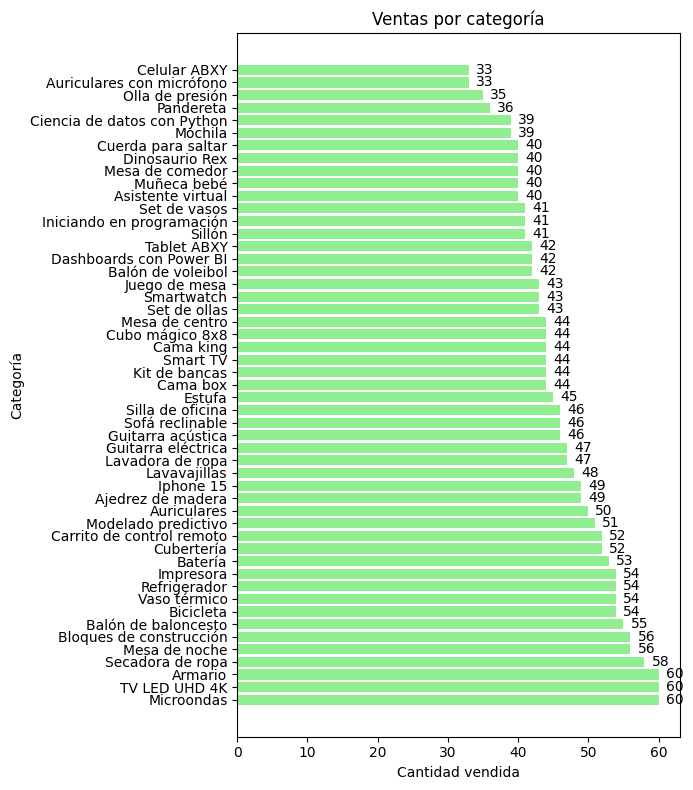

In [18]:
graficas2(producto, ventasP)

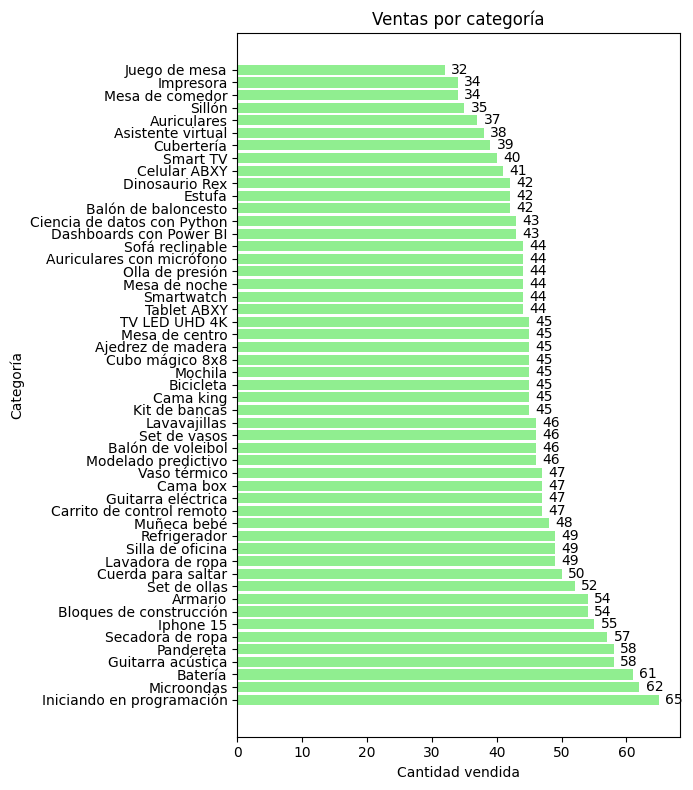

In [19]:
graficas2(producto2, ventasP2)

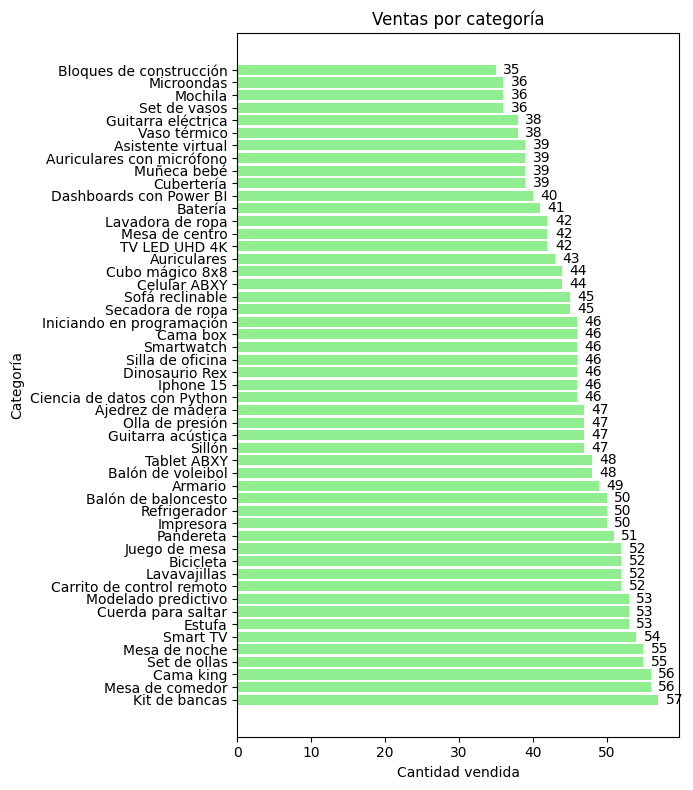

In [20]:
graficas2(producto3, ventasP3)

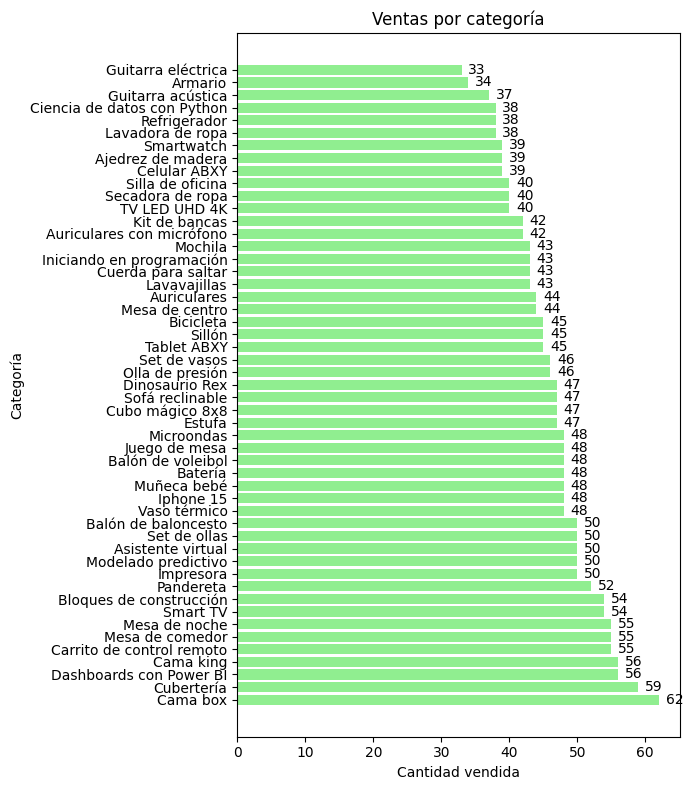

In [21]:
graficas2(producto4, ventasP4)

In [22]:
VentasProductosTienda4

,count
Producto,
Cama box,62
Cubertería,59
Dashboards con Power BI,56
Cama king,56
Carrito de control remoto,55
Mesa de comedor,55
Mesa de noche,55
Smart TV,54
Bloques de construcción,54


# 5. Envío promedio por tienda

In [23]:
EnvioPromedio=tienda["Costo de envío"].mean()
EnvioPromedio2=tienda2["Costo de envío"].mean()
EnvioPromedio3=tienda3["Costo de envío"].mean()
EnvioPromedio4=tienda4["Costo de envío"].mean()

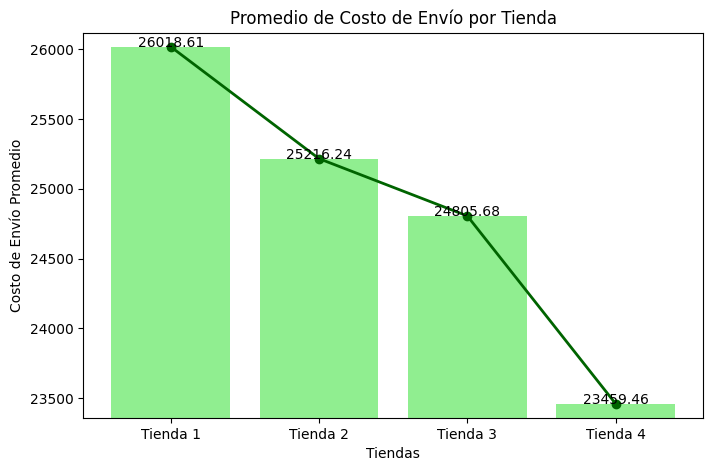

In [24]:
tiendas = ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"]
promedios = [EnvioPromedio, EnvioPromedio2, EnvioPromedio3, EnvioPromedio4]

plt.figure(figsize=(8,5))
plt.bar(tiendas, promedios, color="lightgreen")

# Plot
plt.plot(tiendas, promedios, color="darkgreen", marker="o", linewidth=2)

# Etiquetas
for i, valor in enumerate(promedios):
    plt.text(i, valor + 0.02, f"{valor:.2f}", ha='center')

plt.title("Promedio de Costo de Envío por Tienda")
plt.xlabel("Tiendas")
plt.ylabel("Costo de Envío Promedio")

plt.ylim(min(promedios)-100, max(promedios)+100)

plt.show()

# INFORME FINAL

Introducción

El objetivo de este análisis fue evaluar el desempeño de las cuatro tiendas del Sr. Juan para determinar cuál presenta el menor rendimiento y, por lo tanto, decidir cuál debería venderse para invertir en un nuevo negocio. Para ello se analizaron diversos factores, como los ingresos totales, las categorías de productos más vendidas, las calificaciones promedio de los clientes, los productos con mayor y menor número de ventas y los costos promedio de envío.

Desarrollo

En cuanto a los ingresos totales, la Tienda 1 obtuvo el valor más alto con 1,150,880,400, seguida por la Tienda 2 y la Tienda 3. En contraste, la Tienda 4 presentó los ingresos más bajos con 1,038,375,700, lo que indica un menor desempeño comercial.

Respecto a las categorías de productos, en todas las tiendas destacan principalmente muebles, electrónicos y juguetes, mientras que categorías como artículos para el hogar, instrumentos musicales y libros presentan menores ventas.

En relación con las calificaciones de los clientes, las tiendas tienen valores similares cercanos a 4 puntos. La Tienda 3 tiene la calificación promedio más alta con 4.05, mientras que la Tienda 1 presenta la más baja con 3.98, aunque las diferencias no son muy grandes entre tiendas.

En cuanto a los productos más vendidos, se observa que las tiendas mantienen patrones similares: microondas, televisores, armarios, mesas y camas están entre los más populares, junto con bloques de construcción, balones y artículos electrónicos como auriculares y tablets, mientras que otros productos como juguetes educativos y accesorios complementarios tienen menores ventas.

Finalmente, en cuanto al costo promedio de envío, la Tienda 4 tiene el valor más bajo, mientras que la Tienda 1 presenta el más alto. Sin embargo, esta ventaja no compensa el menor nivel de ingresos que presenta la Tienda 4.

Conclusión

Con base en los resultados obtenidos, se recomienda que el Sr. Juan venda la Tienda 4, ya que es la que presenta el menor nivel de ingresos totales y un desempeño general inferior en comparación con las demás tiendas. De esta manera, podrá invertir esos recursos en un nuevo negocio con mayor potencial de crecimiento.